# Chapter 5 — DDPM + DDIM on MNIST (28×28)

**Theory reference**: `quickguide.tex` Chapter 2 (DDPM) + DDIM sampler.

### What this notebook covers
1. **Forward process** — visualize the noising chain $x_0 \to x_T$ at multiple timesteps
2. **Train DDPM** on MNIST using `SmallUNet` with cosine VP schedule, $T=1000$
3. **DDPM ancestral sampling** — reverse chain $x_T \to x_0$, 1000 steps
4. **DDIM deterministic sampling** — compare NFE = {10, 20, 50, 100, 200}
5. **Progressive denoising** — visualise the reverse chain as a grid
6. **Tweedie prediction** — inspect $\hat{x}_0(x_t, t)$ at different noise levels

### Key equations
**Forward marginal** (quickguide Def 2.1):
$$q(x_t|x_0) = \mathcal{N}(\sqrt{\bar{\alpha}_t}\,x_0,\;(1-\bar{\alpha}_t)I)$$

**Denoising posterior** (quickguide Prop 2.2):
$$q(x_{t-1}|x_t,x_0) = \mathcal{N}(\tilde{\mu}_t,\;\tilde{\beta}_t I), \quad
\tilde{\mu}_t = \frac{\sqrt{\bar{\alpha}_{t-1}}\beta_t}{1-\bar{\alpha}_t}x_0
+ \frac{\sqrt{\alpha_t}(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}x_t$$

**DDIM update** ($\eta=0$, quickguide §2.4):
$$x_{t-1} = \sqrt{\bar{\alpha}_{t-1}}\hat{x}_0 + \sqrt{1-\bar{\alpha}_{t-1}}\,\hat{\varepsilon}_\theta(x_t,t)$$

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

Device: mps


## 0  Data — MNIST in $[-1, 1]$

Batch shape: torch.Size([128, 1, 28, 28])  dtype: torch.float32
Value range: [-1.00, 1.00]


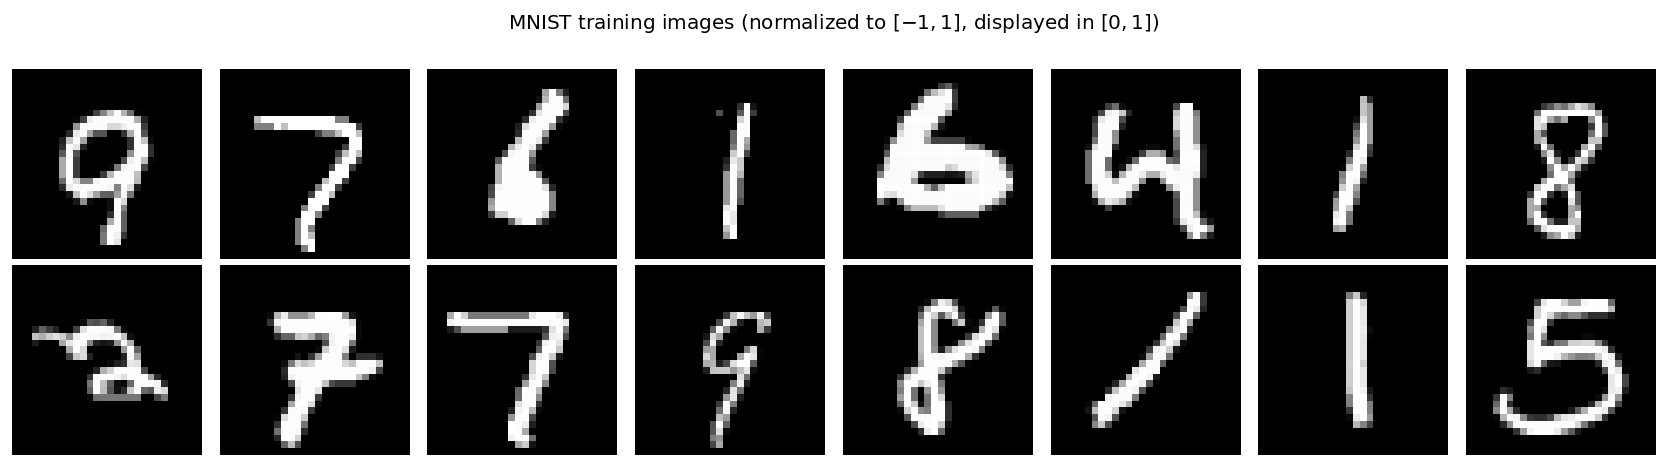

In [2]:
from diffusion_lab.data import get_mnist_loader, denormalize

# Use a small subset for quick experiments; remove n_samples for full training
train_loader = get_mnist_loader(split='train', batch_size=128, num_workers=0)
test_loader  = get_mnist_loader(split='test',  batch_size=64,  num_workers=0)

# Peek at a batch
x_batch, y_batch = next(iter(train_loader))
print(f'Batch shape: {x_batch.shape}  dtype: {x_batch.dtype}')
print(f'Value range: [{x_batch.min():.2f}, {x_batch.max():.2f}]')

# Show a few training images
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(denormalize(x_batch[i]).squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
fig.suptitle('MNIST training images (normalized to $[-1,1]$, displayed in $[0,1]$)')
plt.tight_layout()
plt.show()

## 1  Forward process — noising chain $q(x_t|x_0)$

The VP cosine schedule keeps $\bar{\alpha}_t$ smooth and prevents too-rapid information loss at early timesteps.

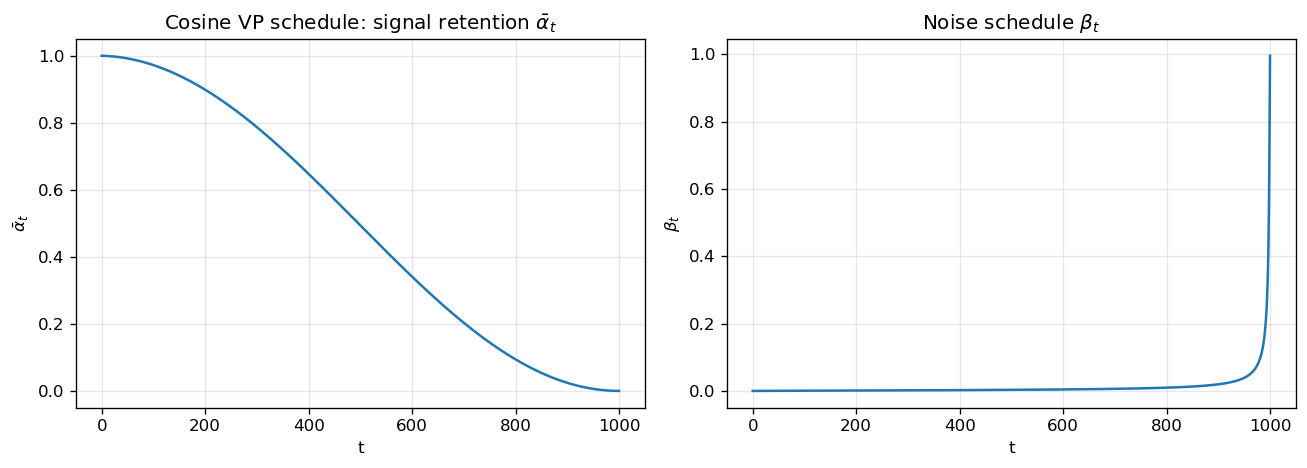

alpha_bar[0]   = 1.0000  (should be ≈1.0)
alpha_bar[500] = 0.4938
alpha_bar[T]   = 0.000000  (should be ≈0)


In [3]:
from diffusion_lab.schedulers import cosine_vp_schedule

T = 1000
sched = cosine_vp_schedule(T=T)

# Plot alpha_bar curve
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ts = torch.arange(T+1)
axes[0].plot(ts.numpy(), sched.alpha_bar.numpy())
axes[0].set_xlabel('t')
axes[0].set_ylabel(r'$\bar{\alpha}_t$')
axes[0].set_title('Cosine VP schedule: signal retention $\\bar{\\alpha}_t$')
axes[0].grid(True, alpha=0.3)

axes[1].plot(ts.numpy(), sched.beta.numpy())
axes[1].set_xlabel('t')
axes[1].set_ylabel(r'$\beta_t$')
axes[1].set_title('Noise schedule $\\beta_t$')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'alpha_bar[0]   = {sched.alpha_bar[0]:.4f}  (should be ≈1.0)')
print(f'alpha_bar[500] = {sched.alpha_bar[500]:.4f}')
print(f'alpha_bar[T]   = {sched.alpha_bar[T]:.6f}  (should be ≈0)')

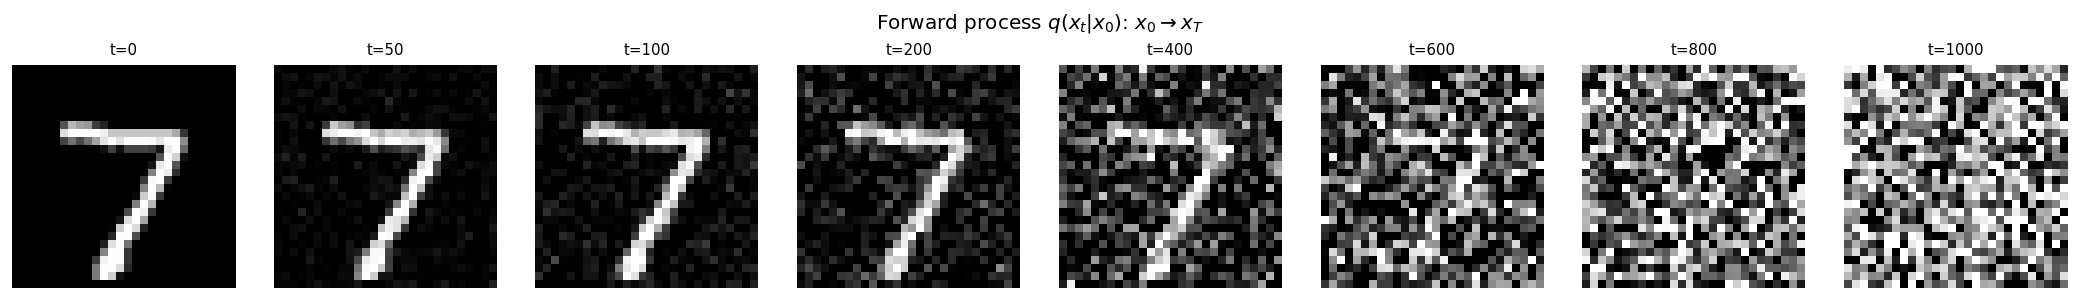

In [4]:
# Visualize forward noising for a single image
x0, _ = next(iter(test_loader))
x0 = x0[:1].to(DEVICE)   # single image
sched_dev = cosine_vp_schedule(T=T).to(DEVICE)

t_show = [0, 50, 100, 200, 400, 600, 800, 1000]

fig, axes = plt.subplots(1, len(t_show), figsize=(2.2*len(t_show), 2.5))
for ax, t_val in zip(axes, t_show):
    if t_val == 0:
        img = x0
    else:
        t_tensor = torch.tensor([t_val], device=DEVICE)
        noise    = torch.randn_like(x0)
        ab = sched_dev.alpha_bar[t_tensor].view(-1, 1, 1, 1)
        img = ab.sqrt() * x0 + (1 - ab).sqrt() * noise
    ax.imshow(denormalize(img.squeeze().cpu()), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f't={t_val}', fontsize=9)
    ax.axis('off')

fig.suptitle(r'Forward process $q(x_t|x_0)$: $x_0 \to x_T$')
plt.tight_layout()
plt.show()

## 2  Build model — SmallUNet + cosine VP schedule

In [5]:
from diffusion_lab.nn     import SmallUNet
from diffusion_lab.models import DDPM

unet = SmallUNet(
    in_channels=1,
    out_channels=1,
    base_channels=32,
    time_embed_dim=128,
    dropout=0.1,
).to(DEVICE)

ddpm = DDPM(
    network=unet,
    schedule=cosine_vp_schedule(T=T).to(DEVICE),
    prediction='epsilon',     # predict noise ε (Ho et al. default) # can choose 'epsilon', 'x0', 'v'
    loss_weight='min_snr',  # min-SNR-γ weighting (Hang et al. 2023)
).to(DEVICE)

n_params = sum(p.numel() for p in unet.parameters())
print(f'SmallUNet parameters: {n_params:,}  (~{n_params/1e6:.2f}M)')

SmallUNet parameters: 1,590,017  (~1.59M)


## 3  Train DDPM

With `base_channels=32`, training takes ~5–20 min on CPU / ~1–3 min on GPU for 20k steps.  
For a quick demo, `n_steps=2000` gives recognizable (if blurry) digit shapes.

In [7]:
from diffusion_lab.training import Trainer

trainer = Trainer(
    model=ddpm,
    loader=train_loader,
    lr=2e-4,
    weight_decay=0.0,
    grad_clip=1.0,
    device=DEVICE,
)

N_STEPS = 20_000   # ← reduce to 2000 for a quick smoke test
losses  = trainer.train(n_steps=N_STEPS, log_every=500)
print(f'Initial loss: {losses[0]:.4f}   Final loss: {losses[-1]:.4f}')

Training:   0%|          | 0/20000 [00:00<?, ?it/s]

Initial loss: 0.8498   Final loss: 0.0264


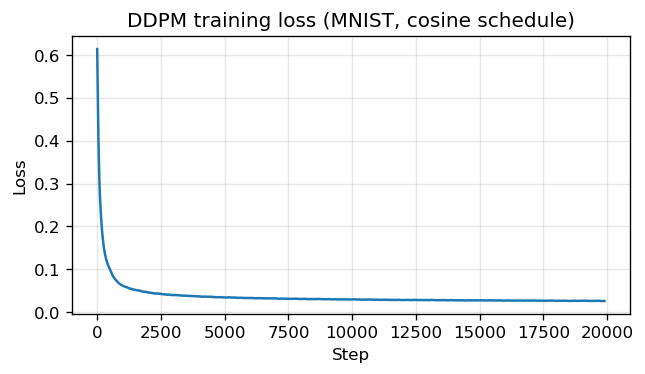

In [8]:
from diffusion_lab.utils import plot_loss_curve
plot_loss_curve(losses, smooth=100, title='DDPM training loss (MNIST, cosine schedule)')
plt.show()

## 4  DDPM ancestral sampling — 1000 reverse steps

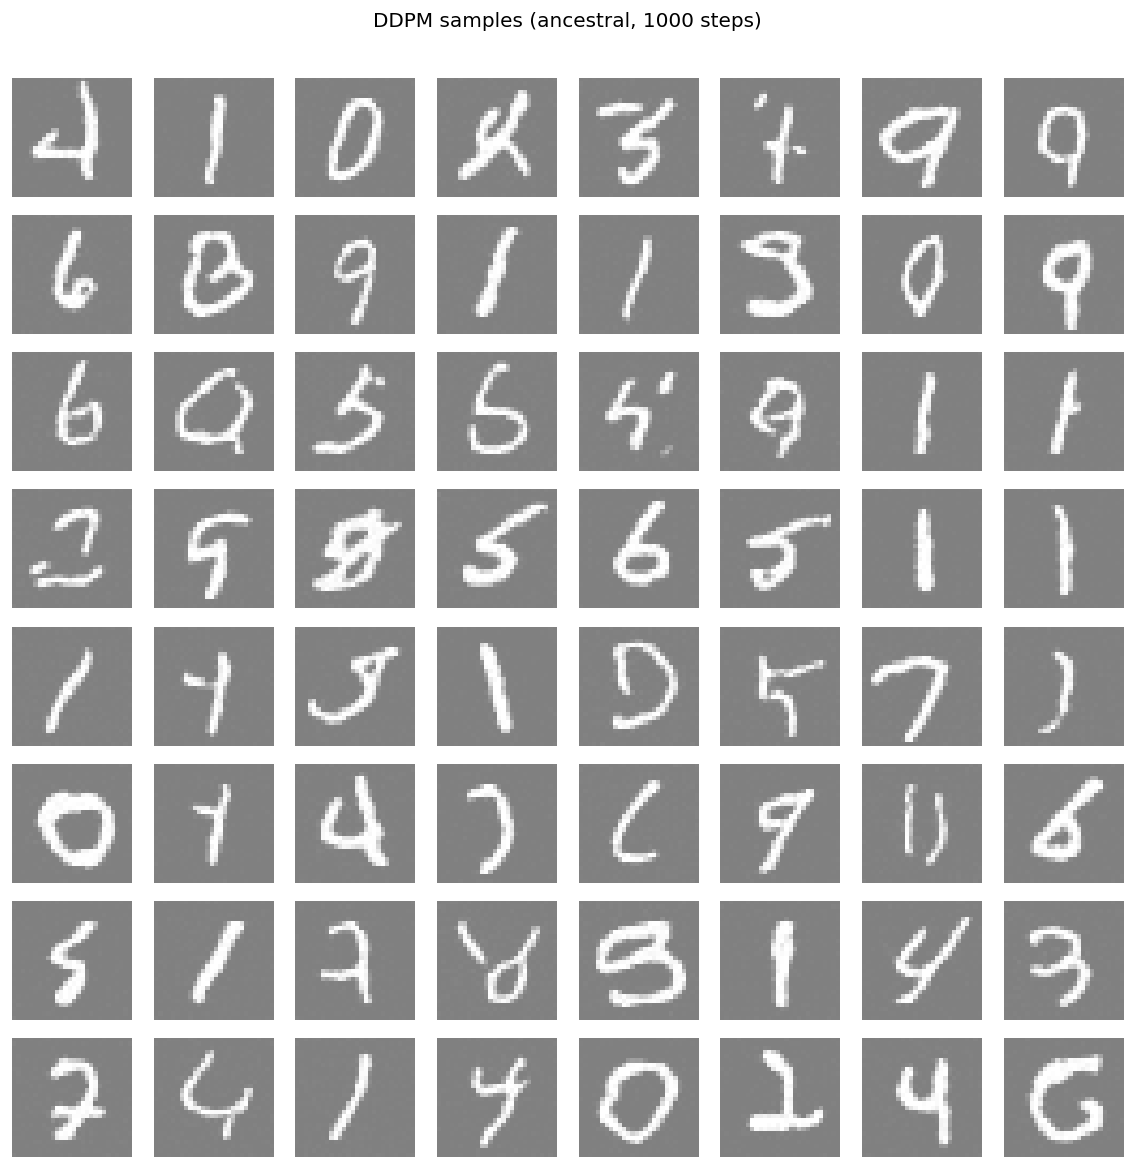

In [9]:
ddpm.eval()

with torch.no_grad():
    x_ddpm = ddpm.sample(
        shape=(64, 1, 28, 28),
        device=DEVICE,
        return_chain=False,
    )

# Display 64 generated samples
from diffusion_lab.utils import show_grid
fig = show_grid(
    denormalize(x_ddpm).cpu(),
    nrow=8,
    title='DDPM samples (ancestral, 1000 steps)',
)
plt.show()

## 5  DDIM deterministic sampling — NFE sweep

DDIM uses the same trained DDPM with $\eta=0$ (no stochasticity):
$$x_{t-1} = \sqrt{\bar{\alpha}_{t-1}}\hat{x}_0 + \sqrt{1-\bar{\alpha}_{t-1}}\,\hat{\varepsilon}_\theta$$

DDIM- 10: done
DDIM- 20: done
DDIM- 50: done
DDIM-100: done
DDIM-200: done


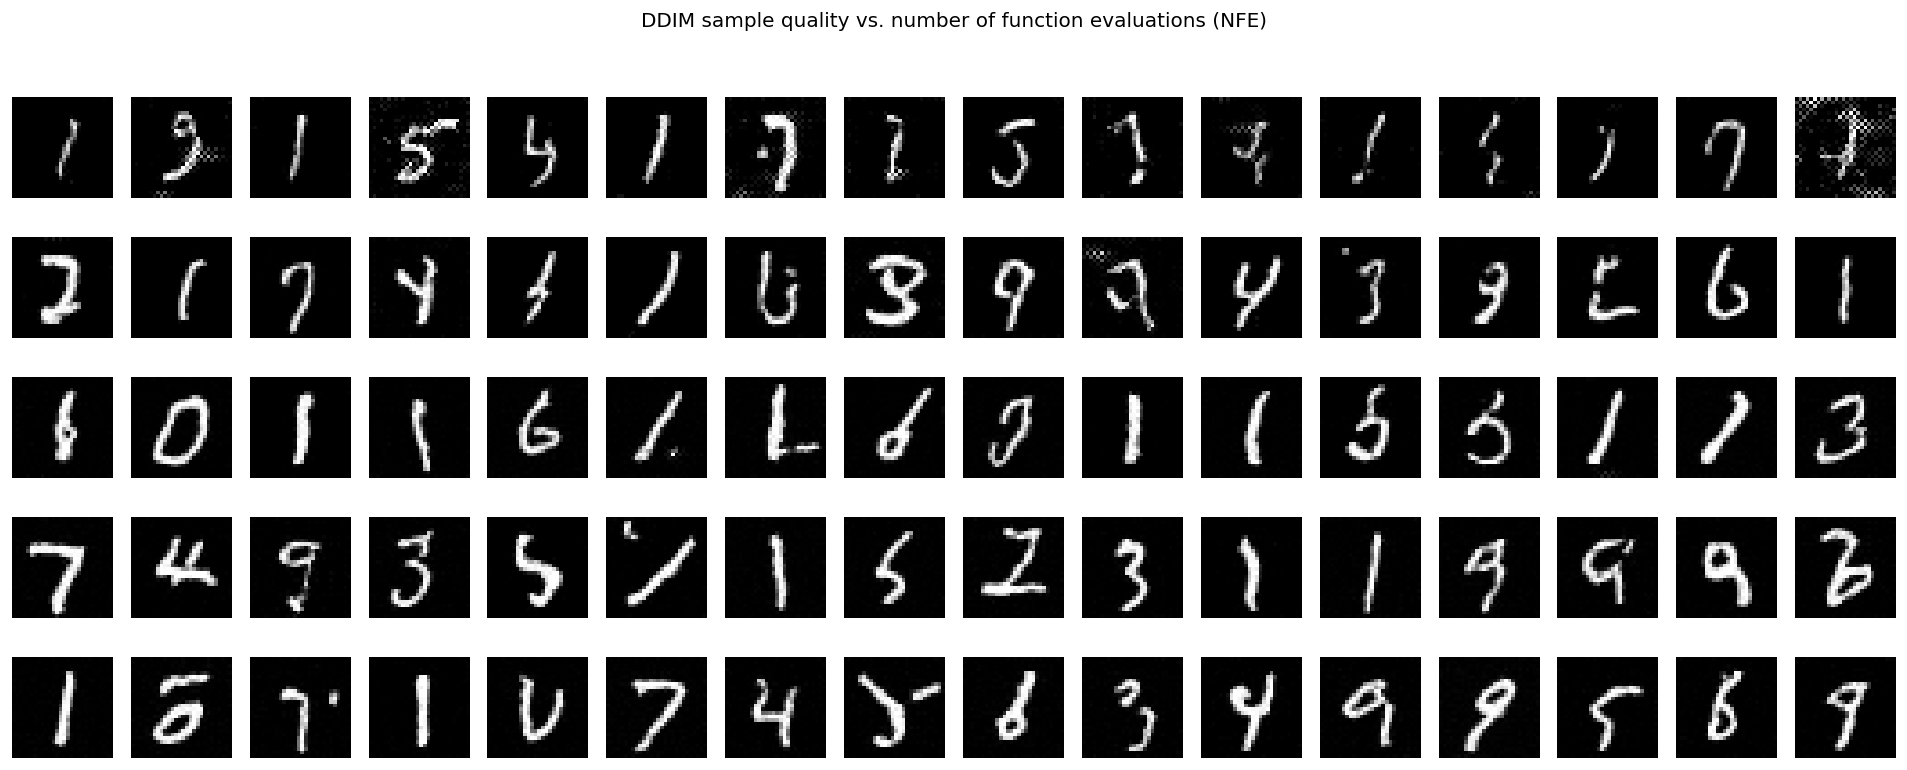

In [10]:
from diffusion_lab.models import DDIMSampler

nfe_list = [10, 20, 50, 100, 200]
ddim_samples = {}

for nfe in nfe_list:
    sampler = DDIMSampler(ddpm, eta=0.0, num_steps=nfe)
    with torch.no_grad():
        xs = sampler.sample((16, 1, 28, 28), device=DEVICE)
    ddim_samples[nfe] = xs
    print(f'DDIM-{nfe:3d}: done')

# Show side-by-side panels
fig, axes = plt.subplots(len(nfe_list), 16, figsize=(16, len(nfe_list)*1.3))
for row, nfe in enumerate(nfe_list):
    xs = denormalize(ddim_samples[nfe]).cpu().numpy()
    for col in range(16):
        axes[row, col].imshow(xs[col, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'DDIM-{nfe}', rotation=0, labelpad=45, va='center', fontsize=9)

fig.suptitle('DDIM sample quality vs. number of function evaluations (NFE)', y=1.01)
plt.tight_layout()
plt.show()

## 6  Progressive denoising chain

Track one reverse trajectory $x_T \to x_{T/2} \to \cdots \to x_0$.

Chain frames: 11


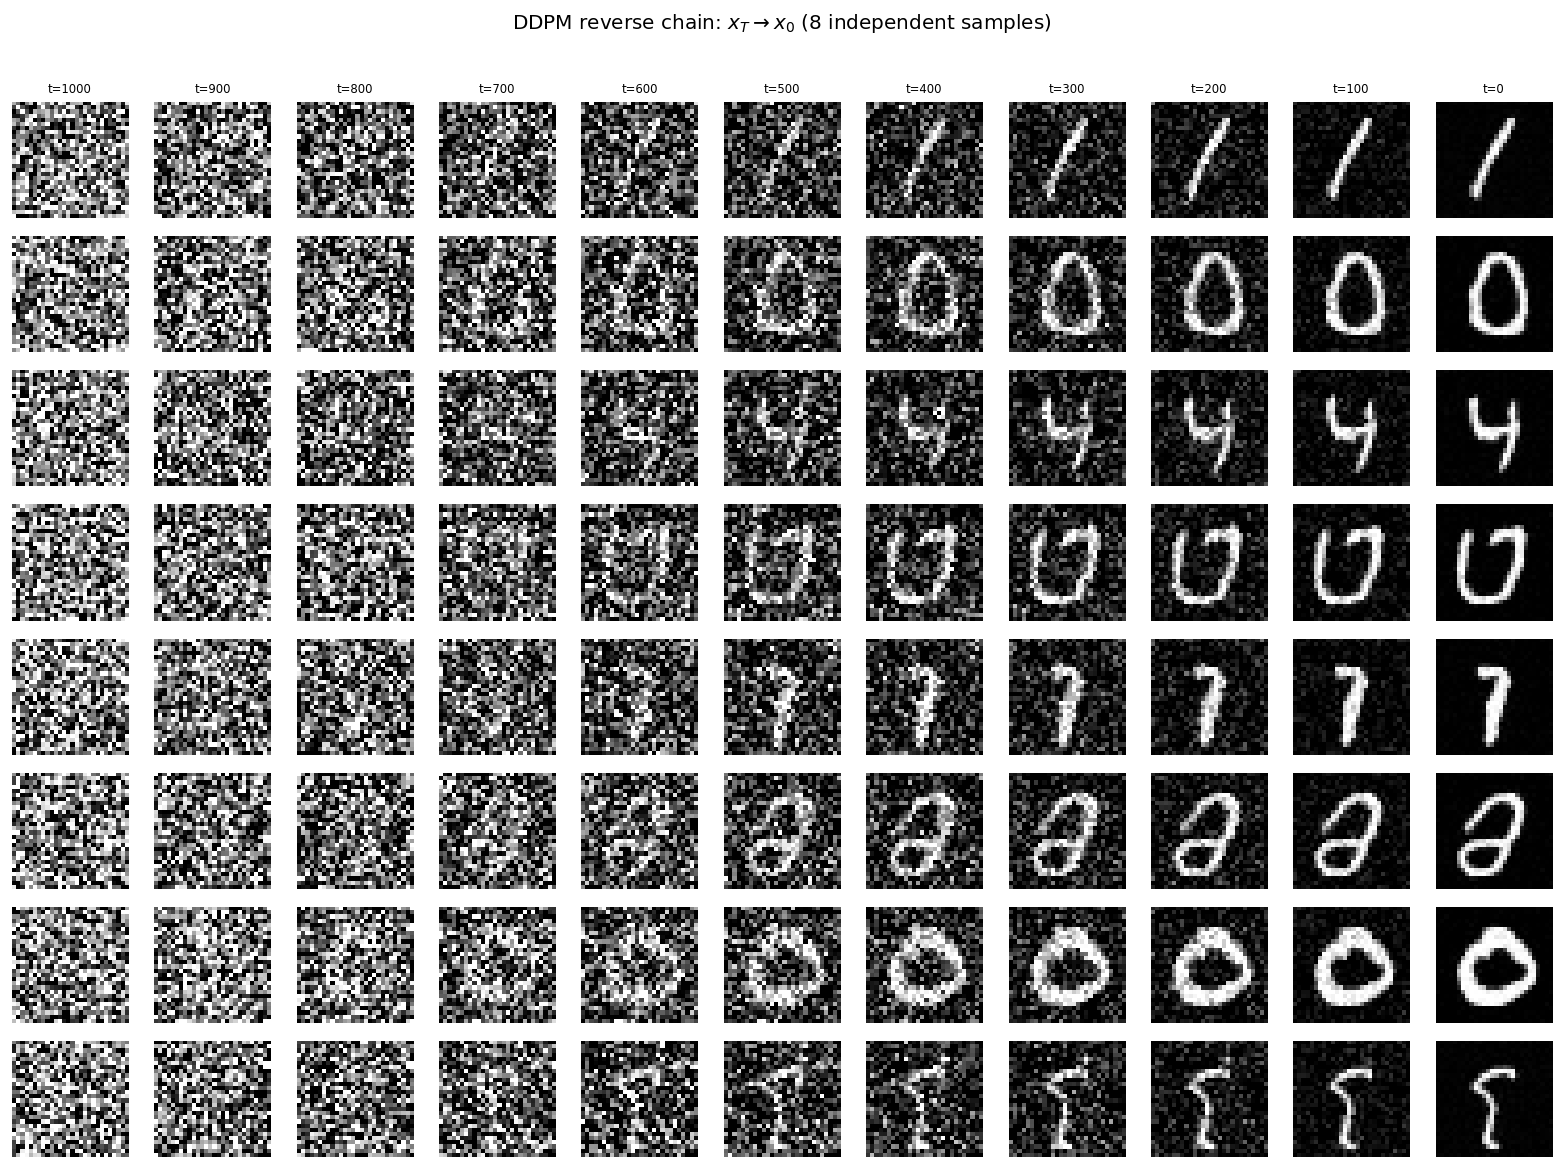

In [11]:
with torch.no_grad():
    chain = ddpm.sample(
        shape=(8, 1, 28, 28),
        device=DEVICE,
        return_chain=True,
        chain_stride=100,    # save every 100 steps → 11 snapshots
    )

n_frames = len(chain)
print(f'Chain frames: {n_frames}')

# Plot: rows = samples, cols = time snapshots
fig, axes = plt.subplots(8, n_frames, figsize=(n_frames * 1.2, 8 * 1.2))
t_labels  = [f't={T - i*100}' for i in range(n_frames)]

for col, (frame, tlabel) in enumerate(zip(chain, t_labels)):
    imgs = denormalize(frame).numpy()   # (8,1,28,28)
    for row in range(8):
        axes[row, col].imshow(imgs[row, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[0, col].set_title(tlabel, fontsize=7)

fig.suptitle('DDPM reverse chain: $x_T \\to x_0$ (8 independent samples)', y=1.01)
plt.tight_layout()
plt.show()

## 7  Tweedie denoised prediction $\hat{x}_0(x_t, t)$

At any noisy image $x_t$, we can form the Tweedie estimate:
$$\hat{x}_0 = \frac{x_t - \sigma_t\,\hat{\varepsilon}_\theta(x_t,t)}{\sqrt{\bar{\alpha}_t}}$$
This should look like a blurry digit at high $t$ and a sharp digit at low $t$.

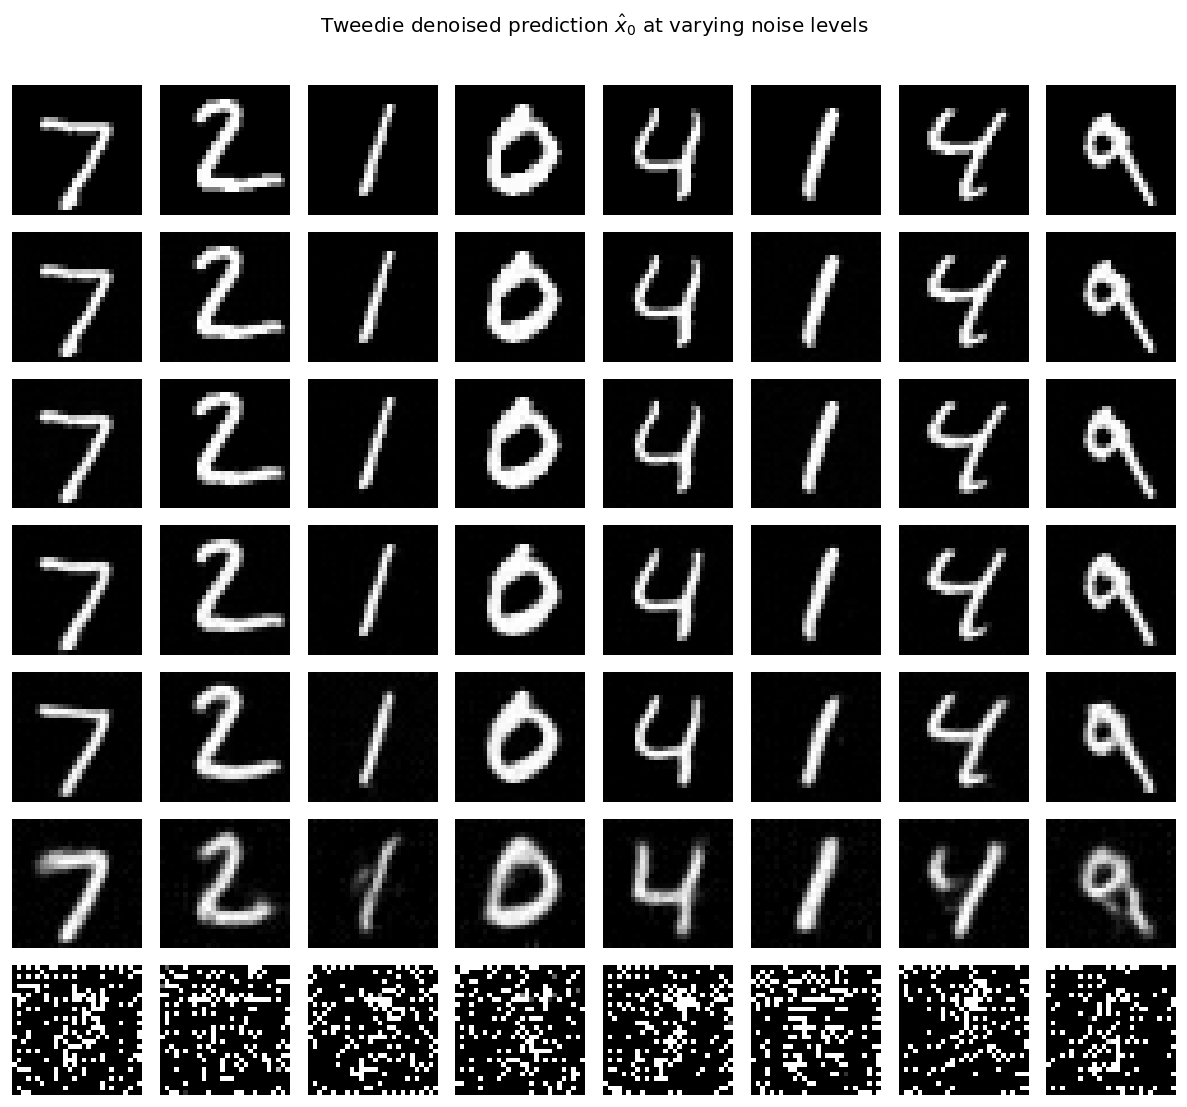

In [12]:
# Take a fixed clean image and corrupt it to various noise levels
x0_fixed, _ = next(iter(test_loader))
x0_fixed = x0_fixed[:8].to(DEVICE)

t_eval = [50, 100, 200, 400, 700, 1000]

ddpm.eval()
fig, axes = plt.subplots(len(t_eval) + 1, 8, figsize=(10, len(t_eval)*1.3 + 1.3))

# Row 0: clean originals
for col in range(8):
    axes[0, col].imshow(denormalize(x0_fixed[col]).squeeze().cpu(), cmap='gray', vmin=0, vmax=1)
    axes[0, col].axis('off')
axes[0, 0].set_ylabel('$x_0$ (clean)', rotation=0, labelpad=55, va='center', fontsize=8)

for row, t_val in enumerate(t_eval, start=1):
    t_tensor = torch.full((8,), t_val, device=DEVICE, dtype=torch.long)
    noise    = torch.randn_like(x0_fixed)
    ab       = sched_dev.alpha_bar[t_tensor].view(-1, 1, 1, 1)
    xt       = ab.sqrt() * x0_fixed + (1 - ab).sqrt() * noise

    with torch.no_grad():
        xt_in   = xt
        t_float = t_tensor.float() / T
        eps_hat = ddpm.network(xt_in, t_float)
        x0_hat  = (xt - (1 - ab).sqrt() * eps_hat) / ab.sqrt()

    for col in range(8):
        axes[row, col].imshow(denormalize(x0_hat[col]).squeeze().cpu().clamp(0,1), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'$\\hat{{x}}_0(x_{{{t_val}}})$', rotation=0, labelpad=55, va='center', fontsize=8)

fig.suptitle(r'Tweedie denoised prediction $\hat{x}_0$ at varying noise levels', y=1.01)
plt.tight_layout()
plt.show()

## 8  Save checkpoint

In [13]:
import pathlib
ckpt_dir = pathlib.Path('../checkpoints')
ckpt_dir.mkdir(exist_ok=True)
trainer.save(str(ckpt_dir / 'ddpm_mnist.pt'))
print('Checkpoint saved to checkpoints/ddpm_mnist.pt')

Checkpoint saved to checkpoints/ddpm_mnist.pt
